# MPRA Library Browser

Interactive notebook for browsing per-variant results from `mpra_empirical_library.py`.

**Features:**
- Browse variants in order (by position, significance, or effect size)
- Per-variant occupancy plots (WT vs variant, all 4 bins)
- Per-variant Δ and significance plots
- Positional p-value heatmaps across the full library
- Cluster detail tables
- Optional coordinate mapping from plasmid to genomic coordinates

In [2]:
import h5py
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ipywidgets import (interact, interactive, Dropdown, IntSlider,
                        ToggleButtons, HBox, VBox, Output, Button,
                        Label, Text, IntText)
from IPython.display import display, clear_output
%matplotlib inline

# ── Configuration ──────────────────────────────────────────────
H5_PATH = '/gscratch/stergachislab/bmallo/large_home/FS_MPRA_results/LDLR_HepG2/LDLR_HEK293T.h5'  # <-- UPDATE THIS
# ──────────────────────────────────────────────────────────────

In [4]:
# ── Load HDF5 ─────────────────────────────────────────────────
f = h5py.File(H5_PATH, 'r')

# ── Load HDF5 ─────────────────────────────────────────────────
f = h5py.File(H5_PATH, 'r')

# bin_labels may be stored as bytes or as str in the HDF5 attrs;
# decode only when necessary
bin_labels = [b.decode() if isinstance(b, (bytes, bytearray)) else str(b)
              for b in f['metadata'].attrs['bin_labels']]

prom_s = int(f['metadata'].attrs['promoter_start'])
prom_e = int(f['metadata'].attrs['promoter_end'])
a_start = int(f['metadata'].attrs.get('analysis_start', 0))
a_end = int(f['metadata'].attrs.get('analysis_end',
            f['metadata'].attrs['reference_length']))
analysis_length = a_end - a_start

BIN_COLORS = {
    'sub-TF_10-19bp': '#66c2a5', 'TF_20-40bp': '#fc8d62',
    'PIC_41-80bp': '#8da0cb', 'Nucleosome_81plusbp': '#e78ac3',
}
BIN_SHORT = {
    'sub-TF_10-19bp': 'sub-TF', 'TF_20-40bp': 'TF',
    'PIC_41-80bp': 'PIC', 'Nucleosome_81plusbp': 'NUC',
}

def sn(name):
    return (name.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('+', 'plus').replace('>', 'to').replace(':', '_'))

print(f'Bins: {bin_labels}')
print(f'Promoter (plasmid): {prom_s}-{prom_e} ({prom_e - prom_s} bp)')
print(f'Analysis region: {a_start}-{a_end} ({analysis_length} bp)')
prom_s = int(f['metadata'].attrs['promoter_start'])
prom_e = int(f['metadata'].attrs['promoter_end'])
a_start = int(f['metadata'].attrs.get('analysis_start', 0))
a_end = int(f['metadata'].attrs.get('analysis_end',
            f['metadata'].attrs['reference_length']))
analysis_length = a_end - a_start

BIN_COLORS = {
    'sub-TF_10-19bp': '#66c2a5', 'TF_20-40bp': '#fc8d62',
    'PIC_41-80bp': '#8da0cb', 'Nucleosome_81plusbp': '#e78ac3',
}
BIN_SHORT = {
    'sub-TF_10-19bp': 'sub-TF', 'TF_20-40bp': 'TF',
    'PIC_41-80bp': 'PIC', 'Nucleosome_81plusbp': 'NUC',
}

def sn(name):
    return (name.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('+', 'plus').replace('>', 'to').replace(':', '_'))

print(f'Bins: {bin_labels}')
print(f'Promoter (plasmid): {prom_s}-{prom_e} ({prom_e - prom_s} bp)')
print(f'Analysis region: {a_start}-{a_end} ({analysis_length} bp)')

Bins: ['sub-TF_10-19bp', 'TF_20-40bp', 'PIC_41-80bp', 'Nucleosome_81plusbp']
Promoter (plasmid): 3184-3501 (317 bp)
Analysis region: 3184-3501 (317 bp)
Bins: ['sub-TF_10-19bp', 'TF_20-40bp', 'PIC_41-80bp', 'Nucleosome_81plusbp']
Promoter (plasmid): 3184-3501 (317 bp)
Analysis region: 3184-3501 (317 bp)


## Coordinate Mapping (Optional)

Map plasmid promoter coordinates to genomic coordinates for display.
Leave chromosome empty to display in plasmid coordinates.

**Both plasmid and genomic coordinates are 1-based inclusive.**

For minus-strand promoters: the rightmost plasmid position maps to the
leftmost genomic position. Data arrays are flipped and bases are complemented.

In [5]:
# ── Coordinate mapping widgets ────────────────────────────────
genomic_chrom_widget = Text(value='', description='Chromosome:',
                            placeholder='e.g. chr19')
genomic_start_widget = IntText(value=0, description='Genomic start:')
genomic_end_widget = IntText(value=0, description='Genomic end:')
strand_widget = ToggleButtons(options=['+', '-'], value='-',
                              description='Strand:')

display(VBox([genomic_chrom_widget, genomic_start_widget,
              genomic_end_widget, strand_widget]))

print('\nFill in above and run the next cell to apply mapping.')
print('Leave chromosome empty for plasmid coordinates.')


Fill in above and run the next cell to apply mapping.
Leave chromosome empty for plasmid coordinates.


In [8]:
# ── Build coordinate mapping functions ────────────────────────
_genomic_chrom = genomic_chrom_widget.value.strip()
_genomic_start = genomic_start_widget.value
_genomic_end = genomic_end_widget.value
_strand = strand_widget.value
_use_genomic = bool(_genomic_chrom) and _genomic_end > _genomic_start

if _use_genomic:
    # Both coords 1-based inclusive; promoter from H5 is 0-based half-open
    promoter_span = prom_e - prom_s
    genomic_span = _genomic_end - _genomic_start + 1
    assert promoter_span == genomic_span, (
        f"Span mismatch: promoter {prom_s}-{prom_e} is {promoter_span} bp "
        f"but genomic {_genomic_chrom}:{_genomic_start}-{_genomic_end} "
        f"is {genomic_span} bp. They must be equal."
    )
    print(f'Coordinate mapping: ACTIVE')
    print(f'  {_genomic_chrom}:{_genomic_start:,}-{_genomic_end:,} ({_strand} strand)')
    if _strand == '-':
        print(f'  Plasmid {prom_e} (right) -> genomic {_genomic_start:,} (left)')
        print(f'  Plasmid {prom_s} (left)  -> genomic {_genomic_end:,} (right)')
        print(f'  Arrays will be FLIPPED; bases COMPLEMENTED.')
    else:
        print(f'  Plasmid {prom_s} (left)  -> genomic {_genomic_start:,} (left)')
        print(f'  Plasmid {prom_e} (right) -> genomic {_genomic_end:,} (right)')
else:
    print('Coordinate mapping: OFF (using plasmid coordinates)')


def get_display_positions():
    if not _use_genomic:
        return np.arange(a_start, a_end)
    return np.arange(_genomic_start, _genomic_end + 1)


def reorient_array(arr):
    if not _use_genomic or _strand == '+':
        return arr
    return arr[::-1]


def reorient_matrix(mat):
    if not _use_genomic or _strand == '+':
        return mat
    return mat[:, ::-1]


def get_display_extent():
    if not _use_genomic:
        return a_start, a_end
    return _genomic_start - 0.5, _genomic_end + 0.5


def get_xlabel():
    if not _use_genomic:
        return 'Plasmid Position (bp)'
    return f'{_genomic_chrom} ({_strand} strand, hg38)'


def plasmid_pos_to_display(pos_0based):
    """Convert 0-based plasmid position to display coordinate.
    PV tag positions are 0-based. Genomic coords are 1-based."""
    if not _use_genomic:
        return pos_0based
    offset = pos_0based - prom_s
    if _strand == '+':
        return _genomic_start + offset
    else:
        return _genomic_end - offset


def convert_variant_label(vid):
    """Convert variant ID from plasmid to genomic coordinates.
    e.g. '6120:t>C' -> '11089351:a>G' (minus strand: complement)"""
    if not _use_genomic:
        return vid
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C',
                  'a': 't', 't': 'a', 'c': 'g', 'g': 'c'}
    match = re.match(r'(\d+):(.*)', vid)
    if not match:
        return vid
    pos_0based = int(match.group(1))
    change = match.group(2)
    genomic_pos = plasmid_pos_to_display(pos_0based)
    if _strand == '-':
        converted = ''.join(complement.get(c, c) for c in change)
    else:
        converted = change
    return f'{genomic_pos}:{converted}'


x_positions = get_display_positions()
print(f'\nDisplay x-range: {x_positions[0]:,} - {x_positions[-1]:,}')

Coordinate mapping: ACTIVE
  chr19:11,089,231-11,089,547 (- strand)
  Plasmid 3501 (right) -> genomic 11,089,231 (left)
  Plasmid 3184 (left)  -> genomic 11,089,547 (right)
  Arrays will be FLIPPED; bases COMPLEMENTED.

Display x-range: 11,089,231 - 11,089,547


In [9]:
# ── Build variant table ───────────────────────────────────────
vg = f['variants']
variant_keys = list(vg.keys())

variants = []
for vk in variant_keys:
    v = vg[vk]
    vid = v.attrs['variant_id']
    try:
        plasmid_pos = int(vid.split(':')[0])
    except (ValueError, IndexError):
        plasmid_pos = 0
    display_pos = plasmid_pos_to_display(plasmid_pos) if plasmid_pos > 0 else 0
    display_label = convert_variant_label(vid)
    variants.append({
        'key': vk, 'id': vid, 'display_label': display_label,
        'plasmid_pos': plasmid_pos, 'display_pos': display_pos,
        'n_reads': int(v.attrs['n_nc_matched']),
        'best_p': float(v.attrs['best_cluster_p']),
        'fdr_q': float(v.attrs.get('variant_fdr_q', 1.0)),
    })

for var in variants:
    v = vg[var['key']]
    max_d = 0.0
    for bl in bin_labels:
        sl = sn(bl)
        if sl in v:
            max_d = max(max_d, np.max(np.abs(v[sl]['delta_obs'][:])))
    var['max_abs_delta'] = max_d

print(f'Loaded {len(variants)} variants')
print(f'Significant (FDR<0.10): {sum(1 for v in variants if v["fdr_q"] < 0.10)}')
print(f'Significant (FDR<0.05): {sum(1 for v in variants if v["fdr_q"] < 0.05)}')
if _use_genomic and variants:
    print(f'\nLabel examples:')
    for v in variants[:5]:
        print(f'  {v["id"]} -> {v["display_label"]} (pos: {v["display_pos"]:,})')

Loaded 132 variants
Significant (FDR<0.10): 123
Significant (FDR<0.05): 117

Label examples:
  3185:2CT -> 11089546:2GA (pos: 11,089,546)
  3186:1T -> 11089545:1A (pos: 11,089,545)
  3187:C>T -> 11089544:G>A (pos: 11,089,544)
  3188:G>T -> 11089543:C>A (pos: 11,089,543)
  3197:G>A -> 11089534:C>T (pos: 11,089,534)


## WT Protein Footprint Landscape

Baseline WT occupancy across all four footprint bins.
This is the reference landscape that variants are compared against.

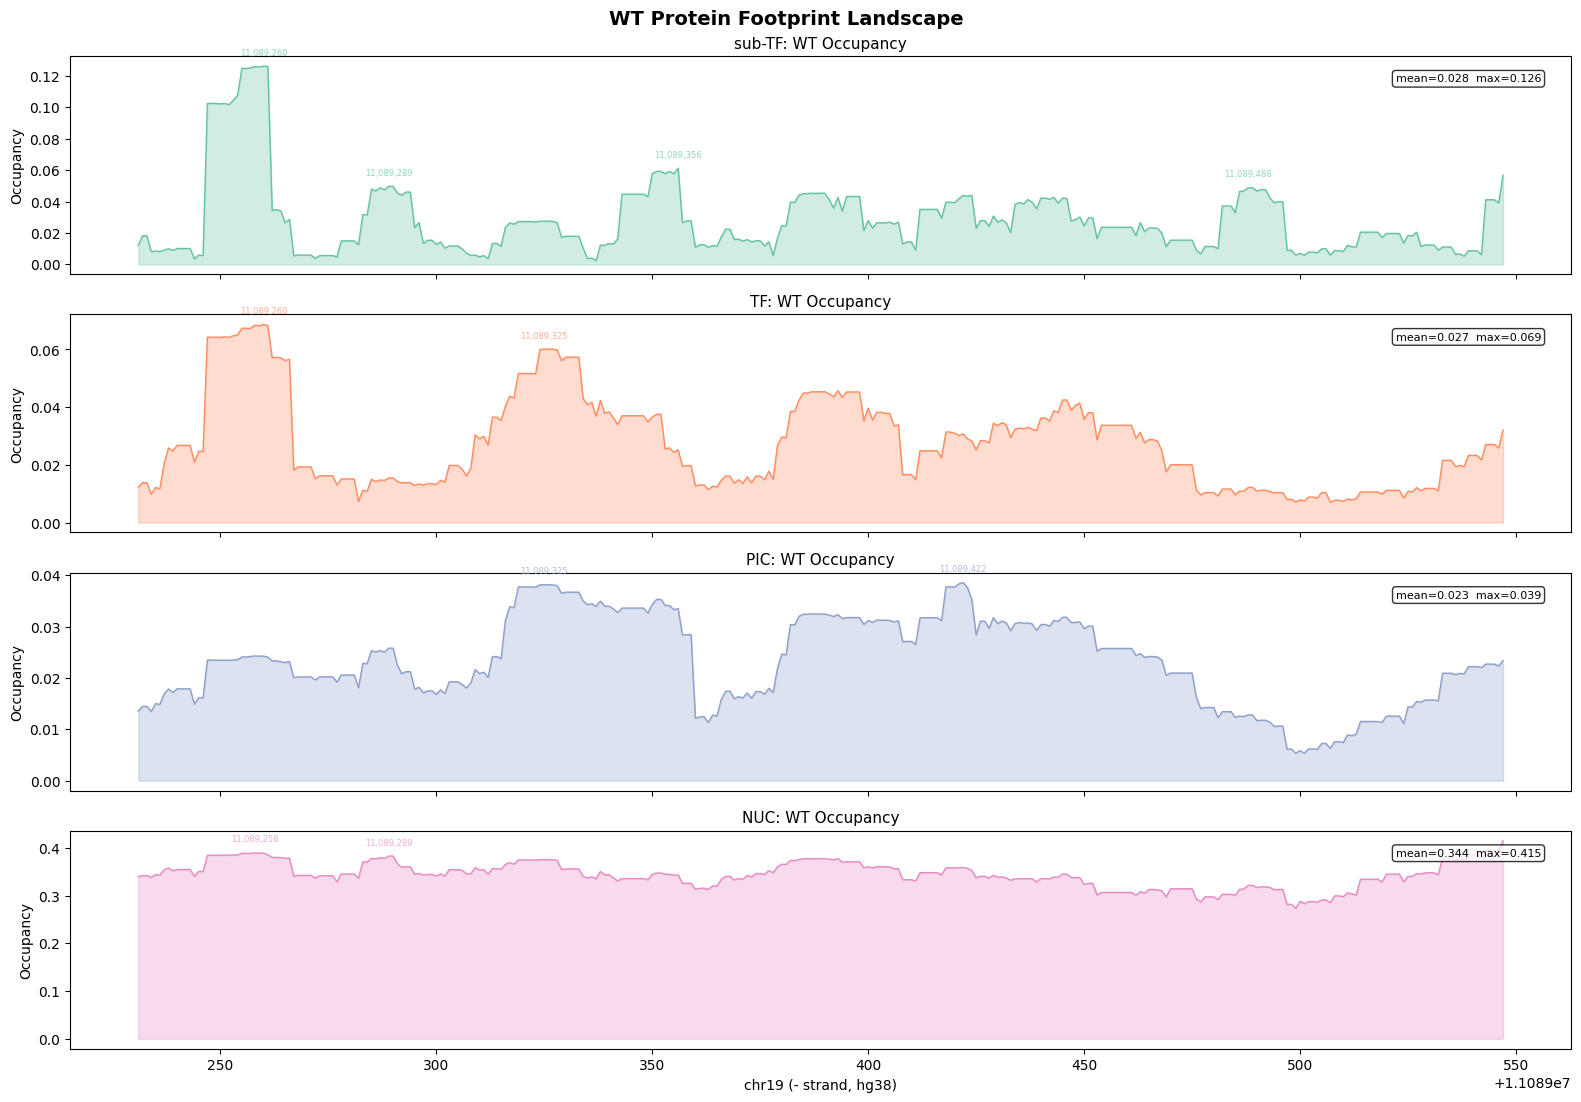

WT Occupancy Summary:
  sub-TF: mean=0.0283  median=0.0232  max=0.1262  >1%: 260 positions
      TF: mean=0.0275  median=0.0249  max=0.0687  >1%: 295 positions
     PIC: mean=0.0233  median=0.0233  max=0.0386  >1%: 300 positions
     NUC: mean=0.3439  median=0.3441  max=0.4149  >1%: 317 positions


In [10]:
# ── WT Protein Footprint Landscape ───────────────────────────
nc_group = f['null_calibration']
first_depth = list(nc_group.keys())[0]

fig, axes = plt.subplots(len(bin_labels), 1,
                         figsize=(16, 2.8 * len(bin_labels)),
                         sharex=True)
if len(bin_labels) == 1:
    axes = [axes]

for i, label in enumerate(bin_labels):
    sl = sn(label)
    color = BIN_COLORS.get(label, 'gray')
    short = BIN_SHORT.get(label, label)
    wt_occ = reorient_array(nc_group[first_depth][sl]['wt_occ'][:])

    ax = axes[i]
    ax.fill_between(x_positions, wt_occ, alpha=0.3, color=color)
    ax.plot(x_positions, wt_occ, linewidth=1, color=color)
    ax.set_ylabel('Occupancy')
    ax.set_title(f'{short}: WT Occupancy', fontsize=11)

    # Annotate peaks
    from scipy.signal import find_peaks
    peaks, props = find_peaks(wt_occ, height=np.percentile(wt_occ, 90),
                              distance=20, prominence=0.01)
    for pk in peaks:
        ax.annotate(f'{x_positions[pk]:,}',
                    xy=(x_positions[pk], wt_occ[pk]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=6, ha='center', color=color, alpha=0.7)

    # Summary stats in legend
    ax.text(0.98, 0.92,
            f'mean={np.mean(wt_occ):.3f}  max={np.max(wt_occ):.3f}',
            transform=ax.transAxes, fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.8))

axes[-1].set_xlabel(get_xlabel())
fig.suptitle('WT Protein Footprint Landscape', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print('WT Occupancy Summary:')
for label in bin_labels:
    sl = sn(label)
    short = BIN_SHORT.get(label, label)
    wt = nc_group[first_depth][sl]['wt_occ'][:]
    print(f'  {short:>6}: mean={np.mean(wt):.4f}  '
          f'median={np.median(wt):.4f}  '
          f'max={np.max(wt):.4f}  '
          f'>1%: {np.sum(wt > 0.01)} positions')

## Sort & Browse Variants

In [11]:
sort_options = {
    'Position (5\' -> 3\')': lambda v: v['display_pos'],
    'Position (3\' -> 5\')': lambda v: -v['display_pos'],
    'Significance (best p)': lambda v: v['best_p'],
    'Effect size (max |d|)': lambda v: -v['max_abs_delta'],
    'Coverage (high -> low)': lambda v: -v['n_reads'],
    'FDR q-value': lambda v: v['fdr_q'],
}
current_sort = {'order': list(range(len(variants)))}

def apply_sort(sort_name):
    key_fn = sort_options[sort_name]
    current_sort['order'] = sorted(range(len(variants)),
                                    key=lambda i: key_fn(variants[i]))
    print(f'Sorted by: {sort_name}')
    for rank, idx in enumerate(current_sort['order'][:5]):
        v = variants[idx]
        print(f'  #{rank+1}: {v["display_label"]} (n={v["n_reads"]}, '
              f'p={v["best_p"]:.4f}, q={v["fdr_q"]:.4f})')

apply_sort('Position (5\' -> 3\')')

Sorted by: Position (5' -> 3')
  #1: 11089231:G>A (n=1659, p=0.0003, q=0.0004)
  #2: 11089233:4TCGA (n=1560, p=0.0003, q=0.0004)
  #3: 11089243:1A (n=1571, p=0.0003, q=0.0004)
  #4: 11089248:1C (n=1895, p=0.0003, q=0.0004)
  #5: 11089251:1A (n=2440, p=0.0002, q=0.0004)


In [12]:
# ── Interactive Variant Browser ───────────────────────────────
sort_toggle = ToggleButtons(
    options=list(sort_options.keys()),
    value='Position (5\' -> 3\')',
    description='Sort:', style={'button_width': '140px'})
variant_slider = IntSlider(
    value=0, min=0, max=len(variants)-1, step=1,
    description='Variant #:', continuous_update=False,
    layout={'width': '600px'})
info_label = Label(value='')
plot_output = Output()

def on_sort_change(change):
    apply_sort(change['new'])
    variant_slider.value = 0
    update_plot(0)
sort_toggle.observe(on_sort_change, names='value')

def update_plot(rank):
    idx = current_sort['order'][rank]
    var = variants[idx]
    vdata = f['variants'][var['key']]
    sig = ('***' if var['fdr_q'] < 0.05 else ('**' if var['fdr_q'] < 0.10
           else ('*' if var['fdr_q'] < 0.20 else '')))
    info_label.value = (f"{var['display_label']}  |  n={var['n_reads']}  |  "
                        f"p={var['best_p']:.4f}  |  q={var['fdr_q']:.4f} {sig}")
    vpos_d = var['display_pos'] if var['display_pos'] != 0 else None

    with plot_output:
        clear_output(wait=True)
        fig, axes = plt.subplots(len(bin_labels), 3,
                                 figsize=(18, 3.2 * len(bin_labels)),
                                 gridspec_kw={'width_ratios': [1.2, 1, 0.8]})
        if len(bin_labels) == 1:
            axes = axes.reshape(1, -1)
        nc_group = f['null_calibration']
        first_depth = list(nc_group.keys())[0]

        for i, label in enumerate(bin_labels):
            sl = sn(label)
            color = BIN_COLORS.get(label, 'gray')
            short = BIN_SHORT.get(label, label)
            if sl not in vdata:
                for ax in axes[i]:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                continue
            lr = vdata[sl]
            delta = reorient_array(lr['delta_obs'][:])
            var_occ = reorient_array(lr['variant_occ'][:])
            emp_p = reorient_array(lr['empirical_p'][:])
            wt_occ = reorient_array(nc_group[first_depth][sl]['wt_occ'][:])

            # Col 1: Occupancy
            ax = axes[i, 0]
            ax.plot(x_positions, wt_occ, color='#4a86c8', lw=1.2, alpha=0.8, label='WT')
            ax.plot(x_positions, var_occ, color='#e85d50', lw=1.2, alpha=0.8, label='Variant')
            ax.set_ylabel('Occupancy'); ax.set_title(f'{short}: Occupancy')
            ax.legend(fontsize=7, frameon=False, loc='upper right')
            if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--', lw=1.2)
            sc_grp = lr.get('significant_clusters')
            if sc_grp:
                for cn in sc_grp.keys():
                    c = sc_grp[cn]
                    cs = plasmid_pos_to_display(int(c.attrs['abs_start']))
                    ce = plasmid_pos_to_display(int(c.attrs['abs_end']))
                    ax.axvspan(min(cs,ce), max(cs,ce), alpha=0.15, color='red')

            # Col 2: Delta
            ax = axes[i, 1]
            ax.fill_between(x_positions, delta, alpha=0.3, color=color)
            ax.plot(x_positions, delta, lw=0.8, color=color)
            ax.axhline(0, color='gray', lw=0.5)
            ax.set_ylabel('Delta'); ax.set_title(f'{short}: Delta')
            if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--', lw=1.2)
            if sc_grp:
                for cn in sc_grp.keys():
                    c = sc_grp[cn]
                    cs = plasmid_pos_to_display(int(c.attrs['abs_start']))
                    ce = plasmid_pos_to_display(int(c.attrs['abs_end']))
                    ax.axvspan(min(cs,ce), max(cs,ce), alpha=0.15, color='red')

            # Col 3: Significance
            ax = axes[i, 2]
            nlp = -np.log10(np.maximum(emp_p, 1e-10))
            ax.plot(x_positions, nlp, lw=0.8, color=color, alpha=0.8)
            ax.axhline(-np.log10(0.05), color='orange', ls='--', lw=0.5)
            ax.axhline(-np.log10(0.01), color='red', ls='--', lw=0.5)
            ax.set_ylabel('-log10(p)'); ax.set_title(f'{short}: Significance')
            if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--', lw=1.2)
            if i == len(bin_labels) - 1:
                for ac in axes[i]: ac.set_xlabel(get_xlabel())

        fig.suptitle(f'Variant: {var["display_label"]}  (n={var["n_reads"]}, '
                     f'p={var["best_p"]:.4f}, FDR q={var["fdr_q"]:.4f})',
                     fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

        # Cluster details
        for label in bin_labels:
            sl = sn(label)
            if sl not in vdata: continue
            sc_grp = vdata[sl].get('significant_clusters')
            if not sc_grp or len(sc_grp) == 0: continue
            short = BIN_SHORT.get(label, label)
            print(f'  {short} clusters:')
            for cn in sorted(sc_grp.keys()):
                c = sc_grp[cn]
                cs = plasmid_pos_to_display(int(c.attrs['abs_start']))
                ce = plasmid_pos_to_display(int(c.attrs['abs_end']))
                cs_d, ce_d = min(cs,ce), max(cs,ce)
                print(f'    [{cs_d:,}-{ce_d:,}] w={c.attrs["width"]}bp '
                      f'sum|d|={c.attrs["sum_abs_delta"]:.3f} '
                      f'p={c.attrs["sum_p"]:.4f} dir={c.attrs["direction"]}')

def on_slider_change(change): update_plot(change['new'])
variant_slider.observe(on_slider_change, names='value')

prev_btn = Button(description='< Prev', layout={'width': '80px'})
next_btn = Button(description='Next >', layout={'width': '80px'})
def on_prev(b):
    if variant_slider.value > 0: variant_slider.value -= 1
def on_next(b):
    if variant_slider.value < variant_slider.max: variant_slider.value += 1
prev_btn.on_click(on_prev); next_btn.on_click(on_next)

display(VBox([sort_toggle, HBox([prev_btn, variant_slider, next_btn]),
              info_label, plot_output]))
update_plot(0)

## Library-Wide Heatmap

Rows = variants (sorted by genomic position), columns = positions.

In [ ]:
pos_sorted = sorted(range(len(variants)), key=lambda i: variants[i]['display_pos'])

@interact(bin_label=Dropdown(options=bin_labels, description='Bin:'),
          metric=Dropdown(options=['-log10(p)', 'Delta (signed)', '|Delta|', 'Z-score'],
                          description='Metric:'))
def plot_heatmap(bin_label, metric):
    sl = sn(bin_label); short = BIN_SHORT.get(bin_label, bin_label)
    n_var = len(pos_sorted)
    heatmap = np.zeros((n_var, analysis_length), dtype=np.float32)
    y_labels = []
    for row, idx in enumerate(pos_sorted):
        var = variants[idx]; y_labels.append(var['display_label'])
        vdata = f['variants'][var['key']]
        if sl not in vdata: continue
        lr = vdata[sl]
        if metric == '-log10(p)':
            heatmap[row,:] = reorient_array(-np.log10(np.maximum(lr['empirical_p'][:], 1e-10)))
        elif metric == 'Delta (signed)':
            heatmap[row,:] = reorient_array(lr['delta_obs'][:])
        elif metric == '|Delta|':
            heatmap[row,:] = reorient_array(np.abs(lr['delta_obs'][:]))
        elif metric == 'Z-score':
            heatmap[row,:] = reorient_array(lr['z_scores'][:])
    el, er = get_display_extent()
    fig, ax = plt.subplots(figsize=(16, max(4, n_var * 0.12)))
    if metric == '-log10(p)':
        im = ax.imshow(heatmap, aspect='auto', cmap='hot_r',
                       vmin=0, vmax=min(np.percentile(heatmap, 99), 4),
                       extent=[el, er, n_var, 0], interpolation='nearest')
    elif metric in ('Delta (signed)', 'Z-score'):
        vm = np.percentile(np.abs(heatmap), 99)
        im = ax.imshow(heatmap, aspect='auto', cmap='RdBu_r',
                       vmin=-vm, vmax=vm, extent=[el, er, n_var, 0],
                       interpolation='nearest')
    else:
        im = ax.imshow(heatmap, aspect='auto', cmap='YlOrRd',
                       vmin=0, vmax=np.percentile(heatmap, 99),
                       extent=[el, er, n_var, 0], interpolation='nearest')
    plt.colorbar(im, ax=ax, label=metric, shrink=0.8)
    if n_var <= 60:
        ax.set_yticks(np.arange(n_var) + 0.5)
        ax.set_yticklabels(y_labels, fontsize=max(4, 8 - n_var//20))
    else:
        ax.set_ylabel(f'Variants (n={n_var})')
    ax.set_xlabel(get_xlabel())
    ax.set_title(f'{short}: {metric}')
    plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='Bin:', options=('sub-TF_10-19bp', 'TF_20-40bp', 'PIC_41-80bp', 'Nu…

## Variant Summary Table

In [14]:
try:
    import pandas as pd; HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False; print('pandas not available')

if HAS_PANDAS:
    rows = []
    for var in variants:
        row = {'variant': var['display_label'], 'position': var['display_pos'],
               'n_reads': var['n_reads'], 'best_p': var['best_p'],
               'fdr_q': var['fdr_q'], 'max_abs_delta': var['max_abs_delta']}
        vdata = f['variants'][var['key']]
        for label in bin_labels:
            sl = sn(label); short = BIN_SHORT.get(label, label)
            if sl in vdata:
                sc = vdata[sl].get('significant_clusters')
                row[f'{short}_clusters'] = len(sc) if sc else 0
                row[f'{short}_max|d|'] = float(np.max(np.abs(vdata[sl]['delta_obs'][:])))
            else:
                row[f'{short}_clusters'] = 0; row[f'{short}_max|d|'] = 0.0
        rows.append(row)
    df = pd.DataFrame(rows).sort_values('best_p')
    def hl(row):
        if row['fdr_q'] < 0.05: return ['background-color: #ffe6e6'] * len(row)
        elif row['fdr_q'] < 0.10: return ['background-color: #fff3e6'] * len(row)
        return [''] * len(row)
    display(df.style.apply(hl, axis=1).format(
        {'best_p': '{:.4f}', 'fdr_q': '{:.4f}', 'max_abs_delta': '{:.4f}'}))
else:
    print(f'{"Variant":<25} {"Pos":>10} {"N":>6} {"best_p":>10} {"FDR_q":>10}')
    for var in sorted(variants, key=lambda v: v['best_p'])[:30]:
        print(f'{var["display_label"]:<25} {var["display_pos"]:>10,} '
              f'{var["n_reads"]:>6} {var["best_p"]:>10.4f} {var["fdr_q"]:>10.4f}')

,variant,position,n_reads,best_p,fdr_q,max_abs_delta,sub-TF_clusters,sub-TF_max|d|,TF_clusters,TF_max|d|,PIC_clusters,PIC_max|d|,NUC_clusters,NUC_max|d|
123,11089266:T>C,11089266,2601,0.0002,0.0004,0.0529,1,0.042223,1,0.052928,1,0.009943,0,0.040133
62,11089397:+C,11089397,587,0.0002,0.0004,0.2174,1,0.046080,3,0.027904,0,0.014137,1,0.217385
36,11089444:A>G,11089444,2109,0.0002,0.0004,0.0329,1,0.029532,2,0.021077,0,0.010606,0,0.032896
127,11089251:1A,11089251,2440,0.0002,0.0004,0.3846,1,0.101714,1,0.064226,1,0.023406,1,0.384650
63,11089395:C>T,11089395,1232,0.0002,0.0004,0.0436,1,0.038380,1,0.021732,1,0.013076,1,0.043597
92,11089341:T>C,11089341,1009,0.0002,0.0004,0.0571,1,0.057065,1,0.023200,0,0.010580,0,0.033048
86,11089353:A>G,11089353,1285,0.0002,0.0004,0.0824,1,0.052195,1,0.020444,1,0.020105,1,0.082392
11,11089513:C>T,11089513,1383,0.0002,0.0004,0.0417,1,0.040194,1,0.017805,0,0.008618,1,0.041731
99,11089326:A>G,11089326,3739,0.0002,0.0004,0.0482,1,0.024081,1,0.020509,1,0.007134,2,0.048158
49,11089415:1C,11089415,3520,0.0002,0.0004,0.3480,2,0.042755,1,0.046703,1,0.031717,1,0.348002


## Positional Sensitivity

In [15]:
@interact(bin_label=Dropdown(options=bin_labels, description='Bin:'),
          y_axis=Dropdown(options=['-log10(best p)', 'max |Delta|', '-log10(FDR q)'],
                          description='Y axis:'))
def positional_sensitivity(bin_label, y_axis):
    sl = sn(bin_label); short = BIN_SHORT.get(bin_label, bin_label)
    positions, values, colors = [], [], []
    for var in variants:
        if var['display_pos'] == 0: continue
        positions.append(var['display_pos'])
        if y_axis == '-log10(best p)':
            values.append(-np.log10(max(var['best_p'], 1e-10)))
        elif y_axis == 'max |Delta|':
            vdata = f['variants'][var['key']]
            values.append(float(np.max(np.abs(vdata[sl]['delta_obs'][:]))) if sl in vdata else 0.0)
        else:
            values.append(-np.log10(max(var['fdr_q'], 1e-10)))
        colors.append('#e85d50' if var['fdr_q'] < 0.05
                      else ('#fc8d62' if var['fdr_q'] < 0.10 else '#aaaaaa'))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.scatter(positions, values, c=colors, s=20, alpha=0.7, edgecolors='none')
    if 'log10' in y_axis:
        ax.axhline(-np.log10(0.05), color='gray', ls='--', lw=0.5)
    ax.set_xlabel(get_xlabel()); ax.set_ylabel(y_axis)
    ax.set_title(f'{short}: {y_axis} by Position (red=FDR<0.05, orange=FDR<0.10, gray=NS)')
    el, er = get_display_extent(); ax.set_xlim(el, er)
    plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='Bin:', options=('sub-TF_10-19bp', 'TF_20-40bp', 'PIC_41-80bp', 'Nu…

## Compare Two Variants

In [ ]:
variant_options = {f"{v['display_label']} (n={v['n_reads']}, q={v['fdr_q']:.3f})": i
                   for i, v in enumerate(variants)}
opt_list = list(variant_options.keys())

@interact(var1=Dropdown(options=opt_list, value=opt_list[0], description='Variant 1:'),
          var2=Dropdown(options=opt_list, value=opt_list[min(1,len(opt_list)-1)], description='Variant 2:'),
          bin_label=Dropdown(options=bin_labels, description='Bin:'))
def compare_variants(var1, var2, bin_label):
    sl = sn(bin_label); short = BIN_SHORT.get(bin_label, bin_label)
    nc_group = f['null_calibration']; fd = list(nc_group.keys())[0]
    wt_occ = reorient_array(nc_group[fd][sl]['wt_occ'][:])
    fig, axes = plt.subplots(2, 3, figsize=(18, 7), gridspec_kw={'width_ratios': [1.2, 1, 0.8]})
    for row, vk in enumerate([var1, var2]):
        idx = variant_options[vk]; var = variants[idx]
        vdata = f['variants'][var['key']]; color = '#e85d50' if row==0 else '#2ca02c'
        vpos_d = var['display_pos'] if var['display_pos'] != 0 else None
        if sl not in vdata:
            for ax in axes[row]: ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        lr = vdata[sl]
        delta = reorient_array(lr['delta_obs'][:])
        vocc = reorient_array(lr['variant_occ'][:])
        ep = reorient_array(lr['empirical_p'][:])
        ax = axes[row,0]
        ax.plot(x_positions, wt_occ, color='#4a86c8', lw=1.2, alpha=0.7, label='WT')
        ax.plot(x_positions, vocc, color=color, lw=1.2, alpha=0.8, label=var['display_label'])
        ax.set_ylabel('Occupancy'); ax.set_title(f'{var["display_label"]} - {short}')
        ax.legend(fontsize=7, frameon=False)
        if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--')
        ax = axes[row,1]
        ax.fill_between(x_positions, delta, alpha=0.3, color=color)
        ax.plot(x_positions, delta, lw=0.8, color=color); ax.axhline(0, color='gray', lw=0.5)
        ax.set_ylabel('Delta'); ax.set_title(f'{var["display_label"]} - Delta')
        if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--')
        ax = axes[row,2]
        ax.plot(x_positions, -np.log10(np.maximum(ep, 1e-10)), lw=0.8, color=color)
        ax.axhline(-np.log10(0.05), color='orange', ls='--', lw=0.5)
        ax.set_ylabel('-log10(p)'); ax.set_title(f'{var["display_label"]} - Significance')
        if vpos_d: ax.axvline(vpos_d, color='red', alpha=0.4, ls='--')
        if row == 1:
            for ac in axes[row]: ac.set_xlabel(get_xlabel())
    plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='Variant 1:', options=('11089546:2GA (n=1497, q=0.000)', '11089545:…

---
*Close HDF5 when done:*

In [ ]:
f.close()
print('HDF5 closed.')